**Problem 1(d) - Simulations of a known regression model**

Solution of Problem 1 (d)
--------------------------------------------------
Coefficient Estimates Table (mean ± std over 1000 simulations):
   Sample Size Full Model (X coef) Reduced Model (X coef)
0          100       3.001 ± 0.117          5.496 ± 0.524
1        10000       3.000 ± 0.011          5.500 ± 0.052


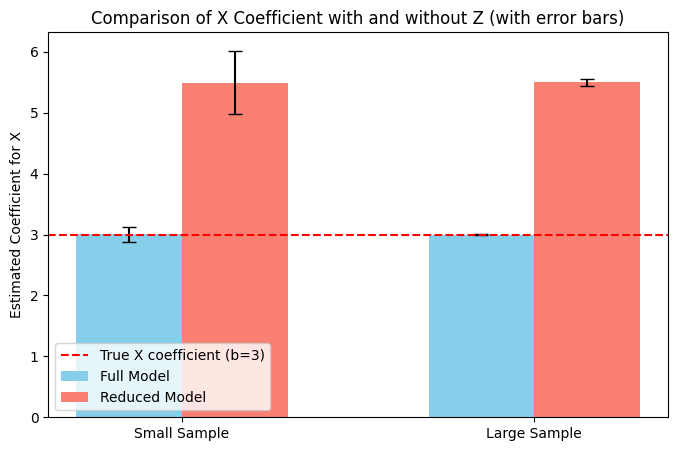

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Solution to Problem 1(d)
print("Solution of Problem 1 (d)")
print("-"*50)

# Set seed and known parameters
np.random.seed(42)
a, b, c = 2, 3, 5
n_simulations = 1000

# Function to simulate models
def simulate_model(n):
    X = np.random.normal(0, 1, n)
    Z = 0.5*X + np.random.normal(0, 1, n)  # Correlated with X
    e = np.random.normal(0, 1, n)
    Y = a + b*X + c*Z + e

    # Full model (X + Z)
    X_full = sm.add_constant(np.column_stack((X, Z)))
    model_full = sm.OLS(Y, X_full).fit()

    # Reduced model (X only)
    X_reduced = sm.add_constant(X)
    model_reduced = sm.OLS(Y, X_reduced).fit()

    return model_full.params[1], model_reduced.params[1]  # Coefficient for X

# Run simulations for small and large sample
def run_simulations(n, n_simulations):
    full_coefs, reduced_coefs = [], []
    for _ in range(n_simulations):
        f, r = simulate_model(n)
        full_coefs.append(f)
        reduced_coefs.append(r)
    return np.mean(full_coefs), np.std(full_coefs), np.mean(reduced_coefs), np.std(reduced_coefs)

# Small and large sample
n_small, n_large = 100, 10000
b_full_small_mean, b_full_small_std, b_red_small_mean, b_red_small_std = run_simulations(n_small, n_simulations)
b_full_large_mean, b_full_large_std, b_red_large_mean, b_red_large_std = run_simulations(n_large, n_simulations)

# Table of results
results_table = pd.DataFrame({
    "Sample Size": [n_small, n_large],
    "Full Model (X coef)": [f"{b_full_small_mean:.3f} ± {b_full_small_std:.3f}",
                            f"{b_full_large_mean:.3f} ± {b_full_large_std:.3f}"],
    "Reduced Model (X coef)": [f"{b_red_small_mean:.3f} ± {b_red_small_std:.3f}",
                               f"{b_red_large_mean:.3f} ± {b_red_large_std:.3f}"]
})
print("Coefficient Estimates Table (mean ± std over 1000 simulations):")
print(results_table)

# Graphical comparison with error bars
labels = ['Small Sample', 'Large Sample']
x_pos = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x_pos - 0.15, [b_full_small_mean, b_full_large_mean], width=0.3, yerr=[b_full_small_std, b_full_large_std],
        capsize=5, label='Full Model', color='skyblue')
plt.bar(x_pos + 0.15, [b_red_small_mean, b_red_large_mean], width=0.3, yerr=[b_red_small_std, b_red_large_std],
        capsize=5, label='Reduced Model', color='salmon')
plt.xticks(x_pos, labels)
plt.ylabel("Estimated Coefficient for X")
plt.title("Comparison of X Coefficient with and without Z (with error bars)")
plt.axhline(b, color='red', linestyle='--', label='True X coefficient (b=3)')
plt.legend()
plt.show()

# Problem 2: Sensitivity of Regression Models to Outliers

## Problem 2b): Simulate and illustrate effect of outliers on OLS regression

True coefficients: intercept = 2.000, slope = 3.000
OLS on clean data: intercept = 2.215, slope = 2.954
OLS with vertical outliers: intercept = 3.547, slope = 2.990
OLS with high-leverage outliers: intercept = 2.103, slope = 2.975


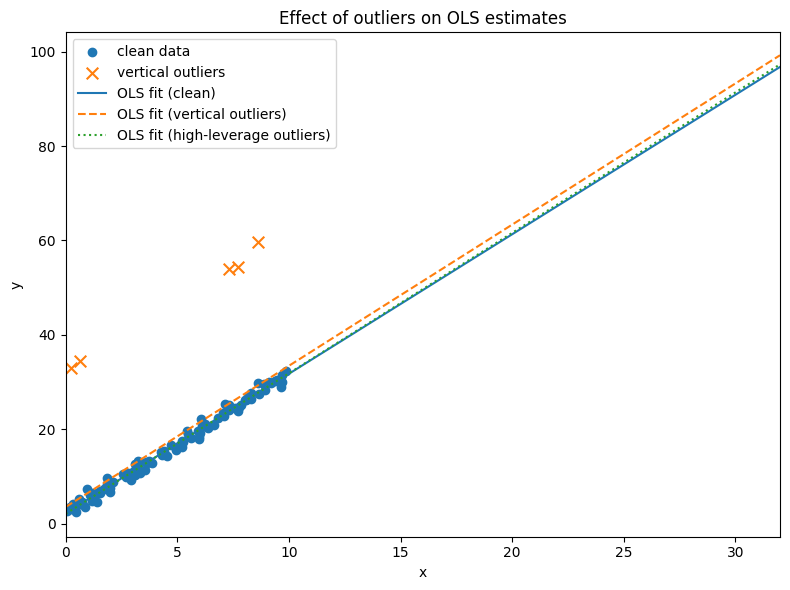

In [2]:
# Simulate and illustrate effect of outliers on OLS regression
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

np.random.seed(42)

def fit_ols(x, y):
    X = np.column_stack([np.ones_like(x), x])
    coef, *_ = lstsq(X, y, rcond=None)
    return coef  # intercept, slope

# 1) Generate clean data
n = 100
x = np.random.uniform(0, 10, size=n)
eps = np.random.normal(0, 1, size=n)
beta0_true, beta1_true = 2.0, 3.0
y_clean = beta0_true + beta1_true * x + eps

coef_clean = fit_ols(x, y_clean)

# 2) Create vertical outliers: add large positive shock to 5% of y
n_out = int(0.05 * n)
idx_out = np.random.choice(n, size=n_out, replace=False)
y_vert = y_clean.copy()
y_vert[idx_out] += 30.0  # large vertical outliers

coef_vert = fit_ols(x, y_vert)

# 3) Create high-leverage outliers: move the same fraction to extreme x values and extreme y
y_lev = y_clean.copy()
x_lev = x.copy()
extreme_x = 30.0
x_lev[idx_out] = extreme_x
y_lev[idx_out] = beta0_true + beta1_true * x_lev[idx_out] + np.random.normal(0,1,size=n_out) + 0.0

coef_lev = fit_ols(x_lev, y_lev)

# Print coefficients
print("True coefficients: intercept = {:.3f}, slope = {:.3f}".format(beta0_true, beta1_true))
print("OLS on clean data: intercept = {:.3f}, slope = {:.3f}".format(coef_clean[0], coef_clean[1]))
print("OLS with vertical outliers: intercept = {:.3f}, slope = {:.3f}".format(coef_vert[0], coef_vert[1]))
print("OLS with high-leverage outliers: intercept = {:.3f}, slope = {:.3f}".format(coef_lev[0], coef_lev[1]))

# Plotting: show clean points, contaminated points, and fitted lines for each model.
plt.figure(figsize=(8,6))
plt.scatter(x, y_clean, label='clean data')  # default colors
plt.scatter(x[idx_out], y_vert[idx_out], marker='x', s=70, label='vertical outliers')
# plot fitted lines
xs = np.linspace(0, 32, 200)
plt.plot(xs, coef_clean[0] + coef_clean[1]*xs, label='OLS fit (clean)')
plt.plot(xs, coef_vert[0] + coef_vert[1]*xs, linestyle='--', label='OLS fit (vertical outliers)')
plt.plot(xs, coef_lev[0] + coef_lev[1]*xs, linestyle=':', label='OLS fit (high-leverage outliers)')
plt.xlim(0, 32)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Effect of outliers on OLS estimates')
plt.legend()
plt.tight_layout()
plt.show()


**Problem 3 - Model Selection**

In [3]:
# QUESTION 3 - Model Selection


import pandas as pd
import statsmodels.api as sm
from itertools import combinations

# -----------------------------
# Load dataset from Google Drive using file ID
# -----------------------------
file_id = "1kndJMrNQxswxYJQcBVZVeMPwlKl4Hs9W"
file_path = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()  # remove any extra spaces

# -----------------------------
# Define dependent and independent variables
# -----------------------------
y = df["Y"]
X = df[["Z1", "Z2", "Z3", "Z4", "Z5"]]

# -----------------------------
# Function: Evaluate all subsets
# -----------------------------
def evaluate_subsets(X, y):
    results = []
    predictors = list(X.columns)
    for k in range(1, len(predictors) + 1):
        for combo in combinations(predictors, k):
            X_subset = sm.add_constant(X[list(combo)])
            model = sm.OLS(y, X_subset).fit()
            results.append({
                "Predictors": combo,
                "Adj_R2": model.rsquared_adj,
                "AIC": model.aic,
                "BIC": model.bic,
                "Model": model
            })
    return pd.DataFrame(results)

# -----------------------------
# Function: Pretty-print regression equation
# -----------------------------
def print_equation(model):
    params = model.params
    eq = f"Y = {params['const']:.3f}"
    for var in params.index[1:]:  # skip intercept
        coef = params[var]
        sign = " + " if coef >= 0 else " - "
        eq += f"{sign}{abs(coef):.3f}{var}"
    return eq

# -----------------------------
# Run all subset evaluations
# -----------------------------
results_df = evaluate_subsets(X, y)

# -----------------------------
# Helper: Show top 5 models for a criterion
# -----------------------------
def show_top_models(results_df, criterion="Adj_R2", ascending=False):
    print(f"\n===== Top 5 Models by {criterion} =====")
    top5 = results_df.sort_values(criterion, ascending=ascending).head()
    for i, row in top5.iterrows():
        print(f"\nModel {i+1}: Predictors {row['Predictors']}")
        print(f"{criterion}: {row[criterion]:.3f}, "
              f"Adj_R2: {row['Adj_R2']:.3f}, AIC: {row['AIC']:.1f}, BIC: {row['BIC']:.1f}")
        print("Equation:", print_equation(row["Model"]))

# -----------------------------
# Display results
# -----------------------------
show_top_models(results_df, criterion="Adj_R2", ascending=False)  # higher is better
show_top_models(results_df, criterion="AIC", ascending=True)      # lower is better
show_top_models(results_df, criterion="BIC", ascending=True)      # lower is better



===== Top 5 Models by Adj_R2 =====

Model 31: Predictors ('Z1', 'Z2', 'Z3', 'Z4', 'Z5')
Adj_R2: 0.994, Adj_R2: 0.994, AIC: -165.9, BIC: -150.3
Equation: Y = 1.010 + 0.449Z1 + 0.299Z2 - 0.406Z3 + 1.008Z4 + 0.257Z5

Model 30: Predictors ('Z2', 'Z3', 'Z4', 'Z5')
Adj_R2: 0.990, Adj_R2: 0.990, AIC: -118.2, BIC: -105.2
Equation: Y = 1.009 + 0.277Z2 - 0.398Z3 + 1.009Z4 + 0.265Z5

Model 29: Predictors ('Z1', 'Z3', 'Z4', 'Z5')
Adj_R2: 0.986, Adj_R2: 0.986, AIC: -86.9, BIC: -73.8
Equation: Y = 1.030 + 0.386Z1 - 0.400Z3 + 1.013Z4 + 0.247Z5

Model 25: Predictors ('Z3', 'Z4', 'Z5')
Adj_R2: 0.983, Adj_R2: 0.983, AIC: -69.4, BIC: -59.0
Equation: Y = 1.028 - 0.394Z3 + 1.013Z4 + 0.254Z5

Model 26: Predictors ('Z1', 'Z2', 'Z3', 'Z4')
Adj_R2: 0.965, Adj_R2: 0.965, AIC: 1.6, BIC: 14.7
Equation: Y = 1.024 + 0.539Z1 + 0.256Z2 - 0.412Z3 + 1.004Z4

===== Top 5 Models by AIC =====

Model 31: Predictors ('Z1', 'Z2', 'Z3', 'Z4', 'Z5')
AIC: -165.902, Adj_R2: 0.994, AIC: -165.9, BIC: -150.3
Equation: Y = 1.010 + 

# Problem 5 :  Stationarity and Unit Roots

## Problem 5b: simulation and plotting for AR(1) processes


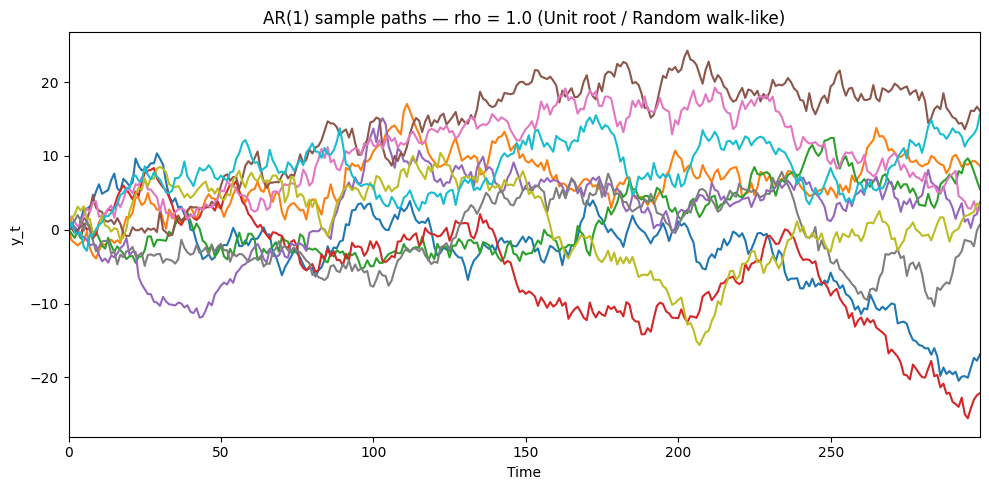

In [4]:
# Re-run simulation and plotting for AR(1) processes
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12345)

def simulate_ar1(rho, n=300, n_paths=10, sigma=1.0):
    eps = np.random.normal(0, sigma, size=(n_paths, n))
    y = np.zeros_like(eps)
    for t in range(1, n):
        y[:, t] = rho * y[:, t-1] + eps[:, t]
    return y

n = 300
n_paths = 10
rho_unit = 1.0
rho_expl = 1.5

y_unit = simulate_ar1(rho_unit, n=n, n_paths=n_paths)
y_expl = simulate_ar1(rho_expl, n=n, n_paths=n_paths)

# Figure 1: sample paths for rho = 1.0 (unit root)
plt.figure(figsize=(10,5))
for i in range(n_paths):
    plt.plot(y_unit[i], label=f'path {i+1}' if i<1 else "")
plt.title('AR(1) sample paths — rho = 1.0 (Unit root / Random walk-like)')
plt.xlabel('Time')
plt.ylabel('y_t')
plt.xlim(0, n-1)
plt.tight_layout()
plt.show()





## Problem 5c simulation and plotting for AR(1) processes

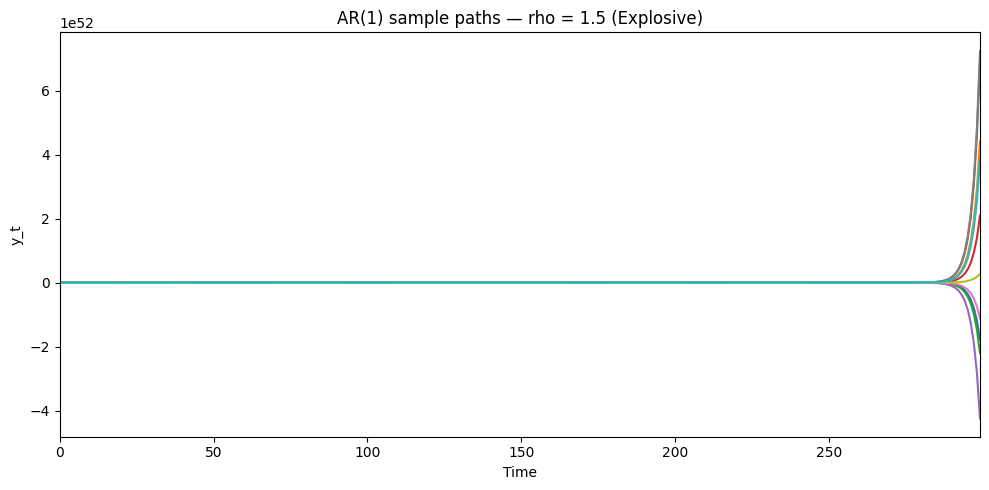

In [5]:
# Figure 2: sample paths for rho = 1.5 (explosive)
plt.figure(figsize=(10,5))
for i in range(n_paths):
    plt.plot(y_expl[i], label=f'path {i+1}' if i<1 else "")
plt.title('AR(1) sample paths — rho = 1.5 (Explosive)')
plt.xlabel('Time')
plt.ylabel('y_t')
plt.xlim(0, n-1)
plt.tight_layout()
plt.show()

## Problem 5c: standard deviation across paths over time for both processes


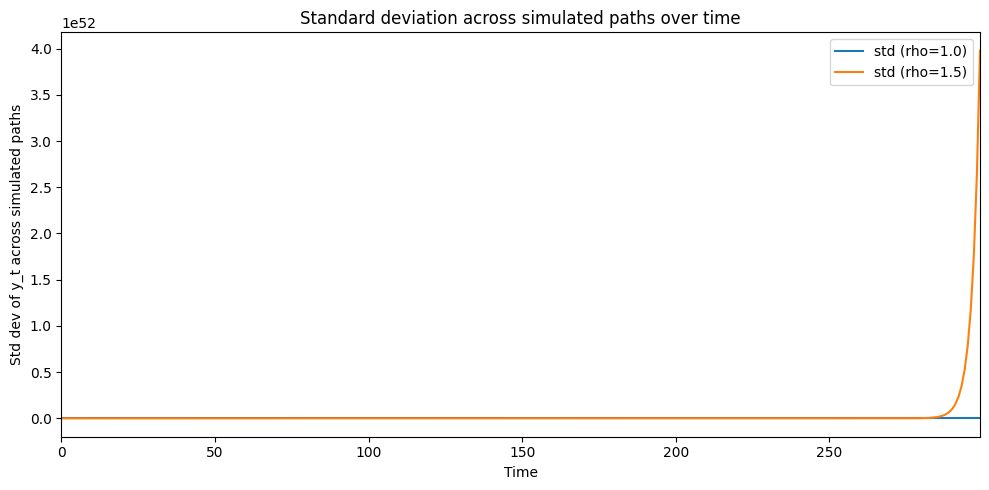

End-of-sample std (rho=1.0): 12.424
End-of-sample std (rho=1.5): 3.9774918643885735e+52
Ratio (explosive / unit): 3.201560162492574e+51


In [6]:
# Figure 3: standard deviation across paths over time for both processes
std_unit = y_unit.std(axis=0, ddof=1)
std_expl = y_expl.std(axis=0, ddof=1)

plt.figure(figsize=(10,5))
plt.plot(std_unit, label='std (rho=1.0)')
plt.plot(std_expl, label='std (rho=1.5)')
plt.title('Standard deviation across simulated paths over time')
plt.xlabel('Time')
plt.ylabel('Std dev of y_t across simulated paths')
plt.legend()
plt.xlim(0, n-1)
plt.tight_layout()
plt.show()

# Print diagnostics
print("End-of-sample std (rho=1.0):", round(std_unit[-1],3))
print("End-of-sample std (rho=1.5):", round(std_expl[-1],3))
print("Ratio (explosive / unit):", round(std_expl[-1] / (std_unit[-1] if std_unit[-1]!=0 else 1),3))


**Problem 6 - MODEL BREAK TESTING**

In [7]:
# QUESTION 6 - MODEL BREAK TESTING

import numpy as np
import statsmodels.api as sm

def slope_break_test(X, Y, break_point=10):
    """
    Tests for a slope change at the specified break point.
    """
    # Step 1: Create dummy variable
    D = np.array([0]*break_point + [1]*(len(X) - break_point))

    # Step 2: Interaction term
    X_star = X * D

    # Step 3: Combine X and X_star as regressors
    X_design = np.column_stack((X, X_star))
    X_design = sm.add_constant(X_design)  # add intercept

    # Step 4: Fit the regression
    model = sm.OLS(Y, X_design).fit()

    # Step 5: Display results
    print(model.summary())

    # Step 6: Interpret the coefficient of X_star
    delta = model.params[2]
    p_value = model.pvalues[2]

    if p_value < 0.05:
        print(f"\nReject H0: δ = 0 (p-value={p_value:.4f}). Evidence of slope change after t={break_point}.")
    else:
        print(f"\nFail to reject H0: δ = 0 (p-value={p_value:.4f}). No evidence of slope change; single slope β is fine.")

# ----------------------------
# Original dataset
# ----------------------------
X1 = np.array([1.2, 2.3, 1.8, 3.0, 2.1, 1.9, 2.5, 3.2, 2.8, 3.1,
               4.0, 3.8, 4.2, 4.5, 3.9, 4.1, 4.3, 4.7, 4.9, 5.0])
Y1 = np.array([2.5, 3.2, 2.8, 4.0, 3.1, 3.0, 3.5, 4.2, 3.9, 4.1,
               5.0, 4.8, 5.1, 5.5, 4.9, 5.2, 5.4, 5.7, 5.8, 6.0])

print("---- Original Dataset ----")
slope_break_test(X1, Y1)

# ----------------------------
# New dataset
# ----------------------------
X2 = np.array([1.2, 2.3, 1.8, 3.0, 2.1, 1.9, 2.5, 3.2, 2.8, 3.1,
               4.0, 3.8, 4.2, 4.5, 3.9, 4.1, 4.3, 4.7, 4.9, 5.0])
Z2 = np.array([2.5, 3.2, 2.8, 4.0, 3.1, 3.0, 3.5, 4.2, 3.9, 4.1,
               50, 48, 51, 55, 49, 52, 54, 57, 58, 60])

print("\n---- New Dataset ----")
slope_break_test(X2, Z2)


---- Original Dataset ----
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     1796.
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           1.67e-20
Time:                        12:18:22   Log-Likelihood:                 23.834
No. Observations:                  20   AIC:                            -41.67
Df Residuals:                      17   BIC:                            -38.68
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2550    